<a href="https://colab.research.google.com/github/freyebeans/ASU-assignments/blob/main/MAT422/HW1.2/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT422 Section 1.2 Linear Algebra
Michael Bishop

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 1.2.1 Linear Spaces
A linear space is close under vector addition and scalar multiplication. Take two vectors in R2, **u** and **v**, we can add these vectors together or multiply by a scalar and still have a vector in R2. A linear combination of these vetors will also still be contained in R2.

In [ ]:
u = np.array([1, 3.2])
v = np.array([5.1, -2.1])
c = 0.7

print("u =", u)
print("v =", v)
print("c =", c)
print("u + v =", u + v)
print("c * v =", c * v)
print("linear combination -4u + v =", -4 * u + v)
print("zero vector =", np.zeros_like(u))
print("additive inverse check v + (-v) =", v + (-v))

u = [1.  3.2]
v = [ 5.1 -2.1]
c = 0.7
u + v = [6.1 1.1]
c * v = [ 3.57 -1.47]
linear combination -4u + v = [  1.1 -14.9]
zero vector = [0. 0.]
additive inverse check v + (-v) = [0. 0.]


The set of vectors in R2 with a norm of 5 would not be an example of a linear space, as most vectors from this set when added to another in the set result in a vector whose norm is not 5.

In [ ]:
w = np.array([0,5])
t = np.array([3,-4])

print("w =", w)
print("norm of w =", np.linalg.norm(w))
print("t =", t)
print("norm of t =", np.linalg.norm(t))
print("t =", t + w)
print("norm of t + w =", np.linalg.norm(t + w))

w = [0 5]
norm of w = 5.0
t = [ 3 -4]
norm of t = 5.0
t = [3 1]
norm of t + w = 3.1622776601683795


As you can see **u** + **v**, c \* **v** and the linear combination of **u** and **v** is also in R2 meaning R2 is a linear space whereas **w** + **t** does not have a norm of 5 and is not in the set of vectors in R2 with a norm of 5, making the set of vectors in R2 with norm 5 not a linear space.
$$
\left|\left|
\begin{bmatrix}
    0\\
    5
\end{bmatrix}
\right|\right|_2 = \sqrt{0^2 + 5^2} = \sqrt{25} = 5\\
\left|\left|
\begin{bmatrix}
    3\\
    -4
\end{bmatrix}
\right|\right|_2 = \sqrt{3^2 + (-4)^2} = \sqrt{25} = 5\\
\left|\left|
\begin{bmatrix}
    3\\
    -4
\end{bmatrix} +
\begin{bmatrix}
    0\\
    5
\end{bmatrix}
\right|\right|_2 = \left|\left|
\begin{bmatrix}
    3\\
    1
\end{bmatrix}
\right|\right|_2 = \sqrt{3^2 + 1^2} = \sqrt{10} \ne 5
$$
## 1.2.2 Orthogonality
Take two vectors **a** and **b**, if the dot product of these two vectors is 0, these vectors are orthogonal. The angle between two orthogonal vectors is 90° and the projection of one onto the other is the zero vector.

a = [1 1 1]
b = [-1 -1  2]
a dot b = 0
angle in degrees = 90.0
vector a projected onto b = [-0. -0.  0.]


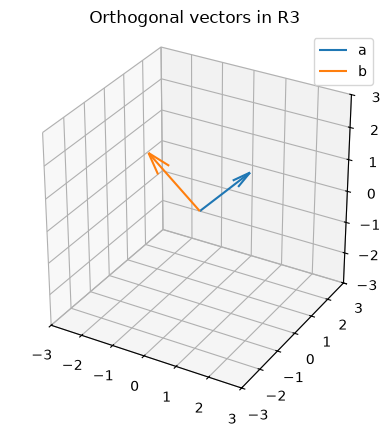

In [ ]:
a = np.array([1,1,1])
b = np.array([-1,-1,2])

adotb = np.dot(a,b)
angle = np.degrees(np.arccos(adotb/(np.linalg.norm(a) * np.linalg.norm(b))))
aprojb = (adotb/np.dot(b,b))*b

print("a =", a)
print("b =", b)
print("a dot b =", adotb)
print("angle in degrees =", angle)
print("vector a projected onto b =", aprojb)

plot = plt.figure().add_subplot(projection='3d')

plt.quiver(0, 0, 0, a[0], a[1], a[2], color="tab:blue", label="a")
plt.quiver(0, 0, 0, b[0], b[1], b[2], color="tab:orange", label="b")
plot.set_xlim(-3, 3)
plot.set_ylim(-3, 3)
plot.set_zlim(-3, 3)
plt.grid(True, alpha=0.3)
plt.gca().set_aspect("equal", adjustable="box")
plt.legend()
plt.title("Orthogonal vectors in R3")
plt.show()

As you can see vectors **a** and **b** have a dot product of 0 making them orthogonal. You can also see that these vectors form a right (90°) angle, both from the calculation of $\arccos(\frac{\textbf{a} \cdot \textbf{b}}{||\textbf{a}|| \cdot ||\textbf{b}||})$ and from the diagram.
$$
\textbf{a} \cdot \textbf{b} = 1 \cdot -1 + 1 \cdot -1 + 1 \cdot 2 = 0\\
\arccos(\frac{\textbf{a} \cdot \textbf{b}}{||\textbf{a}|| \cdot ||\textbf{b}||}) = \arccos(\frac{0}{||\textbf{a}|| \cdot ||\textbf{b}||}) = \arccos(0) = 90^\circ
$$
## 1.2.3 Gram-Schmidt Process
The Gram-Schmidt process converts a set of linearly independent vectors into a new set of of orthonormal vectors for the same span. This is achieved by projecting the vectors onto one another and subtracting that projection from the original, then normalizing.

In [ ]:
def gram_schmidt(columns):
    basis = []
    for x in columns.T:
        y = x.astype(float).copy()
        for q in basis:
            y -= np.dot(q, y) * q
        norm_y = np.linalg.norm(y)
        if norm_y < 1e-12:
            raise ValueError("Input vectors are linearly dependent or nearly dependent.")
        basis.append(y / norm_y)
    return np.column_stack(basis)

A = np.array([
    [2, 1, 0],
    [1, 0, 2],
    [0, 2, 1]])

Q = gram_schmidt(A)
print("original vectors A")
print(A)
print("orthonormalized vectors Q")
print(Q)
print("Q.T * Q")
print(Q.T @ Q)
print("is Q.T * Q close to the identity?",np.allclose(Q.T @ Q, np.eye(3)))

original vectors A
[[2 1 0]
 [1 0 2]
 [0 2 1]]
orthonormalized vectors Q
[[ 0.8944  0.0976 -0.4364]
 [ 0.4472 -0.1952  0.8729]
 [ 0.      0.9759  0.2182]]
Q.T * Q
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
is Q.T * Q close to the identity? True


As you can see $Q^TQ$ is approximately equal to the identity and has been orthonormalized.
## 1.2.4 Eigenvalues and Eigenvectors
Provided a square matrix *A* certain vectors when multiplied by *A*, called eigenvectors, will only be scaled as though it was multiplied by a scalar. The scalar $\lambda$, called an eigenvalue, satisfies the equation $A\textbf{v} = \lambda \textbf{v}$ where **v** is the corresponding eigenvector.

In [ ]:
A = np.array([
    [-5,-6],
    [3,4]])

values, vectors = np.linalg.eig(A)
print("matrix A")
print(A)
print("eigenvalues =",values)
print("eigenvectors (not as columns) =\n",vectors.T)

for i, l in enumerate(values):
    vec = vectors.T[i]
    residual = A @ vec - l * vec
    print(f"\nlambda{i + 1} =", l)
    print(f"v{i + 1} =", vec)
    print(f"A * v{i + 1} =", A @ vec)
    print(f"lambda{i + 1} * v{i + 1} =", l * vec)
    print(f"residual norm {i + 1} (should be about 0) =", np.linalg.norm(residual))

matrix A
[[-5 -6]
 [ 3  4]]
eigenvalues = [-2.  1.]
eigenvectors (not as columns) =
 [[-0.8944  0.4472]
 [ 0.7071 -0.7071]]

lambda1 = -2.0
v1 = [-0.8944  0.4472]
A * v1 = [ 1.7889 -0.8944]
lambda1 * v1 = [ 1.7889 -0.8944]
residual norm 1 (should be about 0) = 2.220446049250313e-16

lambda2 = 1.0
v2 = [ 0.7071 -0.7071]
A * v2 = [ 0.7071 -0.7071]
lambda2 * v2 = [ 0.7071 -0.7071]
residual norm 2 (should be about 0) = 0.0


As you can see here `np.linalg.eig(A)` produces 2 eigenvalues $\lambda _1$ and $\lambda _2$, and 2 eigenvectors $\textbf{v}_1 $ and $\textbf{v}_2$, where $A\textbf{v}_i = \lambda _i \textbf{v}_i$ showing that these two eigenvectors when multiplied by A, are merely scaled.
$$
A\textbf{v}_1 = \lambda _1 \textbf{v}_1\\
\begin{bmatrix}
    -5 & -6\\
    3 & 4
\end{bmatrix}
\begin{bmatrix}
    -2\\
    1
\end{bmatrix}
 = -2
\begin{bmatrix}
    -2\\
    1
\end{bmatrix}\\
-2
\begin{bmatrix}
    -5\\
    3
\end{bmatrix}
+ 1
\begin{bmatrix}
    -6\\
    4
\end{bmatrix}
=
\begin{bmatrix}
    4\\
    -2
\end{bmatrix}
$$
residual
$$
\begin{bmatrix}
    4\\
    -2
\end{bmatrix}
-
\begin{bmatrix}
    4\\
    -2
\end{bmatrix}
= \textbf{0}
$$
`np.linalg.eig()` returns normalized eigenvectors, I chose to work with $\begin{bmatrix}-2\\1\end{bmatrix}$ which is the first vector returned by `np.linalg.eig()` multiplied by $\sqrt{5}$ because integers are easier to work with and the magnitude of an eigenvector has no effect on how well $A\textbf{v}_i = \lambda _i \textbf{v}_i$ holds.
## Reflection and Submission Checklist
- I explained each concpet before and after the code.
- I verified important claims numerically, such as dot products, norms, identities, or residuals.
- I changed and extended at least one example so that the notebook reflects my own work.
- I ran the notebook in its entirety without error.
- I saved the notebook from Google Colab directly to GitHub as per course instructions.